# Clusterização de Municípios Brasileiros — Comparação de Modelos

**Objetivo:** comparar diferentes algoritmos de clusterização sobre o mesmo dataset (municípios brasileiros), incluindo modelos que usam apenas variáveis numéricas, apenas categóricas e mistas:

- **KMeans** (baseline, `02_Baseline`)
- **AgglomerativeClustering** (hierárquico)
- **DBSCAN** e variantes baseadas em densidade: **HDBSCAN**, **OPTICS**
- **KModes** (dados categóricos)
- **KPrototypes** (dados mistos: numéricos + categóricos)

**Estratégia de avaliação justa:** cada modelo é ajustado com o tipo de dado mais adequado a ele (numérico, categórico ou misto), mas **todas as métricas de qualidade são calculadas no mesmo espaço numérico padronizado** (`X_train_num` / `X_test_num`). Isso permite comparar diretamente modelos que usam diferentes representações de entrada.

**Avaliação em teste:** KMeans, KModes e KPrototypes têm método `predict` nativo. Para os demais (Agglomerative, DBSCAN, OPTICS), que não suportam `predict` em novos pontos, os rótulos de teste são obtidos por um classificador `1-NN` treinado com os rótulos de treino (técnica padrão para "estender" clusterizações não paramétricas a novos dados). O HDBSCAN usa sua própria função `approximate_predict`.

## 1. Imports

In [1]:
import os
import warnings

import hdbscan
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from kmodes.kmodes import KModes
from kmodes.kprototypes import KPrototypes
from sklearn.cluster import DBSCAN, AgglomerativeClustering, KMeans, OPTICS
from sklearn.decomposition import PCA
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42

PASTA_REPORTS = "../reports"
PASTA_DATA = "../data"
os.makedirs(PASTA_REPORTS, exist_ok=True)

## 2. Carregar treino/teste (gerados em `02_Baseline`) e preparar as representações numérica, categórica e mista

In [2]:
df_train = pd.read_csv(f"{PASTA_DATA}/municipios_train.csv")
df_test = pd.read_csv(f"{PASTA_DATA}/municipios_test.csv")

COLUNAS_NUMERICAS = [
    "populacao",
    "pib_total_mil_reais",
    "vab_agropecuaria_mil_reais",
    "vab_industria_mil_reais",
    "vab_servicos_mil_reais",
    "vab_adm_publica_mil_reais",
    "pib_per_capita_reais",
]

print("Treino:", df_train.shape, "| Teste:", df_test.shape)

Treino: (4456, 14) | Teste: (1114, 14)


In [3]:
# Representação NUMÉRICA (log1p + padronização, ajustada só no treino) — usada por
# KMeans, Agglomerative, DBSCAN, HDBSCAN, OPTICS, e como espaço comum de avaliação
scaler = StandardScaler()
X_train_num = scaler.fit_transform(np.log1p(df_train[COLUNAS_NUMERICAS]))
X_test_num = scaler.transform(np.log1p(df_test[COLUNAS_NUMERICAS]))

# Representação MISTA (numérica + categórica) — usada por KPrototypes
X_train_mix = np.hstack([X_train_num, df_train[["regiao"]].astype(str).values]).astype(object)
X_test_mix = np.hstack([X_test_num, df_test[["regiao"]].astype(str).values]).astype(object)
IDX_CATEGORICA_MIX = X_train_num.shape[1]  # última coluna = regiao


def discretizar_treino_teste(df_tr, df_te, colunas, n_bins=4):
    """Discretiza colunas numéricas em quartis (calculados no treino) para uso no KModes."""
    labels_bins = [f"q{i+1}" for i in range(n_bins)]
    cat_tr = pd.DataFrame(index=df_tr.index)
    cat_te = pd.DataFrame(index=df_te.index)
    for col in colunas:
        _, bins = pd.qcut(df_tr[col], n_bins, retbins=True, duplicates="drop")
        bins = bins.copy()
        bins[0], bins[-1] = -np.inf, np.inf
        rotulos = labels_bins[: len(bins) - 1]
        cat_tr[col] = pd.cut(df_tr[col], bins=bins, labels=rotulos, include_lowest=True)
        cat_te[col] = pd.cut(df_te[col], bins=bins, labels=rotulos, include_lowest=True)
    return cat_tr, cat_te


# Representação CATEGÓRICA (quartis das variáveis numéricas + região) — usada por KModes
cat_train, cat_test = discretizar_treino_teste(df_train, df_test, COLUNAS_NUMERICAS)
cat_train["regiao"] = df_train["regiao"]
cat_test["regiao"] = df_test["regiao"]
X_train_cat = cat_train.astype(str).values
X_test_cat = cat_test.astype(str).values

print("X_train_num:", X_train_num.shape)
print("X_train_mix:", X_train_mix.shape)
print("X_train_cat:", X_train_cat.shape)

X_train_num: (4456, 7)
X_train_mix: (4456, 8)
X_train_cat: (4456, 8)


## 3. Funções auxiliares de avaliação

In [4]:
resultados = []


def calcular_metricas(X, labels):
    """Silhouette, Calinski-Harabasz e Davies-Bouldin no espaço numérico comum,
    ignorando pontos de ruído (label -1) de modelos baseados em densidade."""
    labels = np.asarray(labels)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    ruido = float(np.mean(labels == -1))

    if n_clusters < 2 or (labels != -1).sum() < 2:
        return dict(n_clusters=n_clusters, fracao_ruido=ruido,
                    silhouette=np.nan, calinski_harabasz=np.nan, davies_bouldin=np.nan)

    mask = labels != -1
    Xm, lm = X[mask], labels[mask]
    return dict(
        n_clusters=n_clusters,
        fracao_ruido=ruido,
        silhouette=silhouette_score(Xm, lm),
        calinski_harabasz=calinski_harabasz_score(Xm, lm),
        davies_bouldin=davies_bouldin_score(Xm, lm),
    )


def registrar_resultado(modelo, conjunto, labels, params=""):
    metricas = calcular_metricas(X_train_num if conjunto == "treino" else X_test_num, labels)
    resultados.append({"modelo": modelo, "conjunto": conjunto, "parametros": params, **metricas})
    return metricas


def rotular_teste_via_knn(X_train, labels_train, X_test, ignorar_ruido=True):
    """'Estende' uma clusterização sem `predict` nativo a novos pontos via 1-NN."""
    labels_train = np.asarray(labels_train)
    mask = labels_train != -1 if ignorar_ruido else np.ones(len(labels_train), dtype=bool)
    if mask.sum() == 0 or len(set(labels_train[mask])) < 2:
        return np.full(len(X_test), -1)
    knn = KNeighborsClassifier(n_neighbors=1).fit(X_train[mask], labels_train[mask])
    return knn.predict(X_test)

## 4. KMeans (baseline)

In [5]:
melhor_k, melhor_sil = None, -1
for k in range(2, 9):
    labels_k = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit_predict(X_train_num)
    sil = silhouette_score(X_train_num, labels_k)
    if sil > melhor_sil:
        melhor_k, melhor_sil = k, sil

kmeans = KMeans(n_clusters=melhor_k, random_state=RANDOM_STATE, n_init=10).fit(X_train_num)
labels_train_kmeans = kmeans.labels_
labels_test_kmeans = kmeans.predict(X_test_num)

print(f"KMeans — k escolhido: {melhor_k}")
registrar_resultado("KMeans", "treino", labels_train_kmeans, params=f"k={melhor_k}")
registrar_resultado("KMeans", "teste", labels_test_kmeans, params=f"k={melhor_k}")

KMeans — k escolhido: 2


{'n_clusters': 2,
 'fracao_ruido': 0.0,
 'silhouette': 0.4054991293596194,
 'calinski_harabasz': 929.4099921046923,
 'davies_bouldin': 0.9755050152778686}

## 5. AgglomerativeClustering

In [6]:
melhor_k, melhor_sil = None, -1
for k in range(2, 9):
    labels_k = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(X_train_num)
    sil = silhouette_score(X_train_num, labels_k)
    if sil > melhor_sil:
        melhor_k, melhor_sil = k, sil

agglo = AgglomerativeClustering(n_clusters=melhor_k, linkage="ward")
labels_train_agglo = agglo.fit_predict(X_train_num)
# AgglomerativeClustering não tem `predict`: rotula o teste via 1-NN a partir do treino
labels_test_agglo = rotular_teste_via_knn(X_train_num, labels_train_agglo, X_test_num)

print(f"Agglomerative — k escolhido: {melhor_k}")
registrar_resultado("Agglomerative", "treino", labels_train_agglo, params=f"k={melhor_k}")
registrar_resultado("Agglomerative", "teste", labels_test_agglo, params=f"k={melhor_k}")

Agglomerative — k escolhido: 2


{'n_clusters': 2,
 'fracao_ruido': 0.0,
 'silhouette': 0.3981507550549492,
 'calinski_harabasz': 826.3910824007477,
 'davies_bouldin': 0.9864823330993009}

## 6. DBSCAN

Primeiro, o gráfico de distância ao k-ésimo vizinho ajuda a escolher candidatos de `eps`.

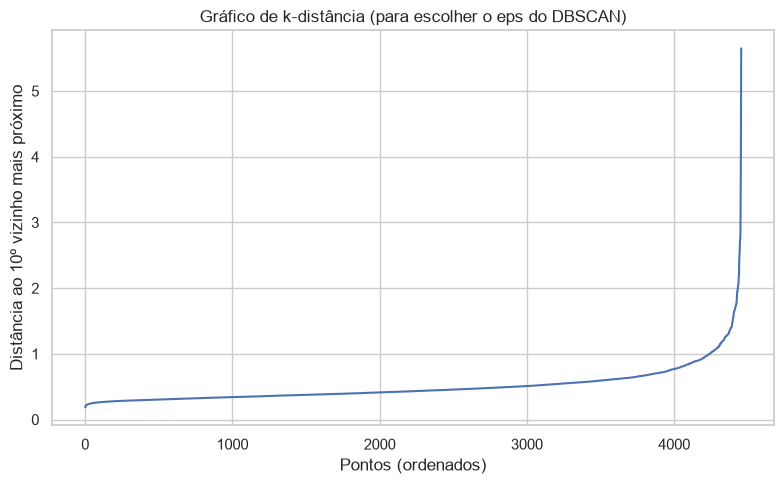

In [7]:
MIN_SAMPLES = 10

from sklearn.neighbors import NearestNeighbors

vizinhos = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_train_num)
distancias, _ = vizinhos.kneighbors(X_train_num)
k_distancias = np.sort(distancias[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(k_distancias)
plt.xlabel("Pontos (ordenados)")
plt.ylabel(f"Distância ao {MIN_SAMPLES}º vizinho mais próximo")
plt.title("Gráfico de k-distância (para escolher o eps do DBSCAN)")
plt.tight_layout()
plt.savefig(f"{PASTA_REPORTS}/comparacao_dbscan_kdistancia.png", dpi=120)
plt.show()

In [8]:
# Candidatos de eps a partir de percentis do gráfico de k-distância
candidatos_eps = np.percentile(k_distancias, [80, 85, 90, 92, 94, 96, 98])

melhor_eps, melhor_sil, melhor_labels = None, -1, None
for eps in candidatos_eps:
    labels_eps = DBSCAN(eps=eps, min_samples=MIN_SAMPLES).fit_predict(X_train_num)
    m = calcular_metricas(X_train_num, labels_eps)
    # só considera configurações com pelo menos 2 clusters e ruído controlado
    if m["n_clusters"] >= 2 and m["fracao_ruido"] < 0.5 and not np.isnan(m["silhouette"]):
        if m["silhouette"] > melhor_sil:
            melhor_eps, melhor_sil, melhor_labels = eps, m["silhouette"], labels_eps

if melhor_eps is None:
    print("Nenhuma configuração satisfatória encontrada; usando o maior eps candidato.")
    melhor_eps = candidatos_eps[-1]
    melhor_labels = DBSCAN(eps=melhor_eps, min_samples=MIN_SAMPLES).fit_predict(X_train_num)

dbscan = DBSCAN(eps=melhor_eps, min_samples=MIN_SAMPLES)
labels_train_dbscan = melhor_labels
labels_test_dbscan = rotular_teste_via_knn(X_train_num, labels_train_dbscan, X_test_num)

print(f"DBSCAN — eps escolhido: {melhor_eps:.3f}, min_samples={MIN_SAMPLES}")
registrar_resultado("DBSCAN", "treino", labels_train_dbscan, params=f"eps={melhor_eps:.2f}")
registrar_resultado("DBSCAN", "teste", labels_test_dbscan, params=f"eps={melhor_eps:.2f}")

DBSCAN — eps escolhido: 0.606, min_samples=10


{'n_clusters': 2,
 'fracao_ruido': 0.0,
 'silhouette': 0.5148014337391944,
 'calinski_harabasz': 230.03058506220086,
 'davies_bouldin': 0.6071814339190621}

## 7. HDBSCAN (variante do DBSCAN com densidade variável)

In [9]:
melhor_mcs, melhor_sil, melhor_labels, melhor_modelo = None, -1, None, None
for min_cluster_size in [15, 30, 50, 100, 150]:
    modelo_hdb = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, prediction_data=True)
    labels_mcs = modelo_hdb.fit_predict(X_train_num)
    m = calcular_metricas(X_train_num, labels_mcs)
    if m["n_clusters"] >= 2 and m["fracao_ruido"] < 0.7 and not np.isnan(m["silhouette"]):
        if m["silhouette"] > melhor_sil:
            melhor_mcs, melhor_sil = min_cluster_size, m["silhouette"]
            melhor_labels, melhor_modelo = labels_mcs, modelo_hdb

if melhor_modelo is None:
    print("Nenhuma configuração satisfatória encontrada; usando o menor min_cluster_size candidato.")
    melhor_mcs = 15
    melhor_modelo = hdbscan.HDBSCAN(min_cluster_size=melhor_mcs, prediction_data=True)
    melhor_labels = melhor_modelo.fit_predict(X_train_num)

labels_train_hdbscan = melhor_labels
labels_test_hdbscan, _ = hdbscan.approximate_predict(melhor_modelo, X_test_num)

print(f"HDBSCAN — min_cluster_size escolhido: {melhor_mcs}")
registrar_resultado("HDBSCAN", "treino", labels_train_hdbscan, params=f"min_cluster_size={melhor_mcs}")
registrar_resultado("HDBSCAN", "teste", labels_test_hdbscan, params=f"min_cluster_size={melhor_mcs}")

Nenhuma configuração satisfatória encontrada; usando o menor min_cluster_size candidato.


HDBSCAN — min_cluster_size escolhido: 15


{'n_clusters': 3,
 'fracao_ruido': 0.8868940754039497,
 'silhouette': 0.2396385983479864,
 'calinski_harabasz': 9.649682842952705,
 'davies_bouldin': 0.6969749921676821}

## 8. OPTICS (outra variante baseada em densidade)

In [10]:
optics = OPTICS(min_samples=MIN_SAMPLES, xi=0.05)
labels_train_optics = optics.fit_predict(X_train_num)
labels_test_optics = rotular_teste_via_knn(X_train_num, labels_train_optics, X_test_num)

print("OPTICS — min_samples:", MIN_SAMPLES, "| xi:", 0.05)
registrar_resultado("OPTICS", "treino", labels_train_optics, params="min_samples=10, xi=0.05")
registrar_resultado("OPTICS", "teste", labels_test_optics, params="min_samples=10, xi=0.05")

OPTICS — min_samples: 10 | xi: 0.05


{'n_clusters': 9,
 'fracao_ruido': 0.0,
 'silhouette': 0.1623860598354475,
 'calinski_harabasz': 354.71035251886775,
 'davies_bouldin': 1.5320909181969613}

## 9. KModes (variáveis categóricas: quartis das numéricas + região)

In [11]:
melhor_k, melhor_sil, melhor_modelo, melhor_labels = None, -1, None, None
for k in range(2, 7):
    km_cat = KModes(n_clusters=k, init="Huang", n_init=5, random_state=RANDOM_STATE, verbose=0)
    labels_k = km_cat.fit_predict(X_train_cat)
    sil = calcular_metricas(X_train_num, labels_k)["silhouette"]
    if not np.isnan(sil) and sil > melhor_sil:
        melhor_k, melhor_sil, melhor_modelo, melhor_labels = k, sil, km_cat, labels_k

kmodes_model = melhor_modelo
labels_train_kmodes = melhor_labels
labels_test_kmodes = kmodes_model.predict(X_test_cat)

print(f"KModes — k escolhido: {melhor_k} (custo do modelo: {kmodes_model.cost_:.1f})")
registrar_resultado("KModes", "treino", labels_train_kmodes, params=f"k={melhor_k}")
registrar_resultado("KModes", "teste", labels_test_kmodes, params=f"k={melhor_k}")

KModes — k escolhido: 2 (custo do modelo: 19031.0)


{'n_clusters': 2,
 'fracao_ruido': 0.0,
 'silhouette': 0.3117968462834153,
 'calinski_harabasz': 703.3504710099442,
 'davies_bouldin': 1.1313336670198946}

## 10. KPrototypes (variáveis numéricas + região)

In [12]:
melhor_k, melhor_sil, melhor_modelo, melhor_labels = None, -1, None, None
for k in range(2, 7):
    kp = KPrototypes(n_clusters=k, init="Huang", n_init=2, random_state=RANDOM_STATE, verbose=0)
    labels_k = kp.fit_predict(X_train_mix, categorical=[IDX_CATEGORICA_MIX])
    sil = calcular_metricas(X_train_num, labels_k)["silhouette"]
    if not np.isnan(sil) and sil > melhor_sil:
        melhor_k, melhor_sil, melhor_modelo, melhor_labels = k, sil, kp, labels_k

kprototypes_model = melhor_modelo
labels_train_kproto = melhor_labels
labels_test_kproto = kprototypes_model.predict(X_test_mix, categorical=[IDX_CATEGORICA_MIX])

print(f"KPrototypes — k escolhido: {melhor_k} (custo do modelo: {kprototypes_model.cost_:.1f})")
registrar_resultado("KPrototypes", "treino", labels_train_kproto, params=f"k={melhor_k}")
registrar_resultado("KPrototypes", "teste", labels_test_kproto, params=f"k={melhor_k}")

KPrototypes — k escolhido: 2 (custo do modelo: 18369.4)


{'n_clusters': 2,
 'fracao_ruido': 0.0,
 'silhouette': 0.4066111002063448,
 'calinski_harabasz': 929.2649956359185,
 'davies_bouldin': 0.9731865058606037}

## 11. Tabela comparativa de métricas

In [13]:
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados[
    ["modelo", "conjunto", "parametros", "n_clusters", "fracao_ruido",
     "silhouette", "calinski_harabasz", "davies_bouldin"]
]
df_resultados.to_csv(f"{PASTA_REPORTS}/comparacao_modelos.csv", index=False)

df_resultados.sort_values(["conjunto", "silhouette"], ascending=[True, False])

,modelo,conjunto,parametros,n_clusters,fracao_ruido,silhouette,calinski_harabasz,davies_bouldin
5,DBSCAN,teste,eps=0.61,2,0.000000,0.514801,230.030585,0.607181
13,KPrototypes,teste,k=2,2,0.000000,0.406611,929.264996,0.973187
1,KMeans,teste,k=2,2,0.000000,0.405499,929.409992,0.975505
3,Agglomerative,teste,k=2,2,0.000000,0.398151,826.391082,0.986482
11,KModes,teste,k=2,2,0.000000,0.311797,703.350471,1.131334
7,HDBSCAN,teste,min_cluster_size=15,3,0.886894,0.239639,9.649683,0.696975
9,OPTICS,teste,"min_samples=10, xi=0.05",9,0.000000,0.162386,354.710353,1.532091
8,OPTICS,treino,"min_samples=10, xi=0.05",9,0.972846,0.650337,855.482311,0.487607
4,DBSCAN,treino,eps=0.61,2,0.109515,0.481059,77.320307,0.425875
12,KPrototypes,treino,k=2,2,0.000000,0.413011,3724.368084,0.971572


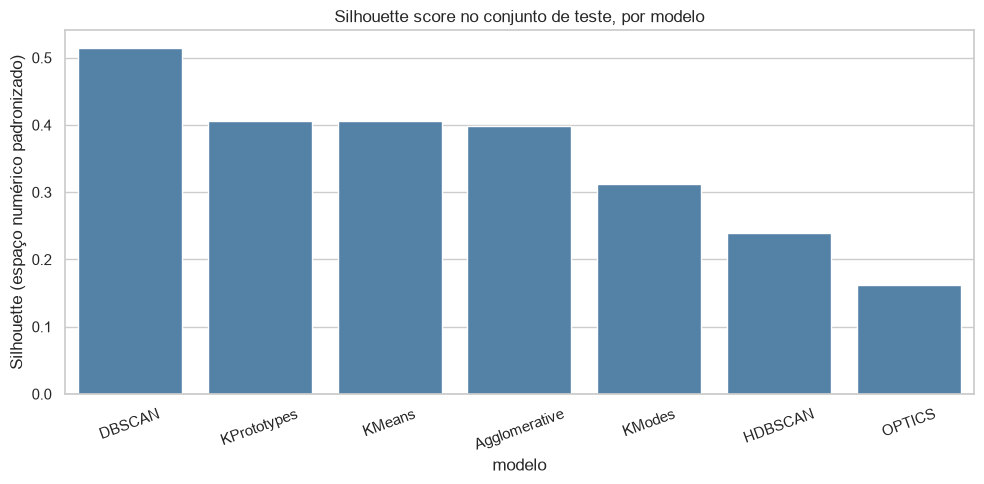

In [14]:
plt.figure(figsize=(10, 5))
teste = df_resultados[df_resultados["conjunto"] == "teste"].sort_values("silhouette", ascending=False)
sns.barplot(data=teste, x="modelo", y="silhouette", color="steelblue")
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Silhouette score no conjunto de teste, por modelo")
plt.ylabel("Silhouette (espaço numérico padronizado)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(f"{PASTA_REPORTS}/comparacao_silhouette_teste.png", dpi=120)
plt.show()

## 12. Visualização dos clusters (PCA 2D, conjunto de teste)

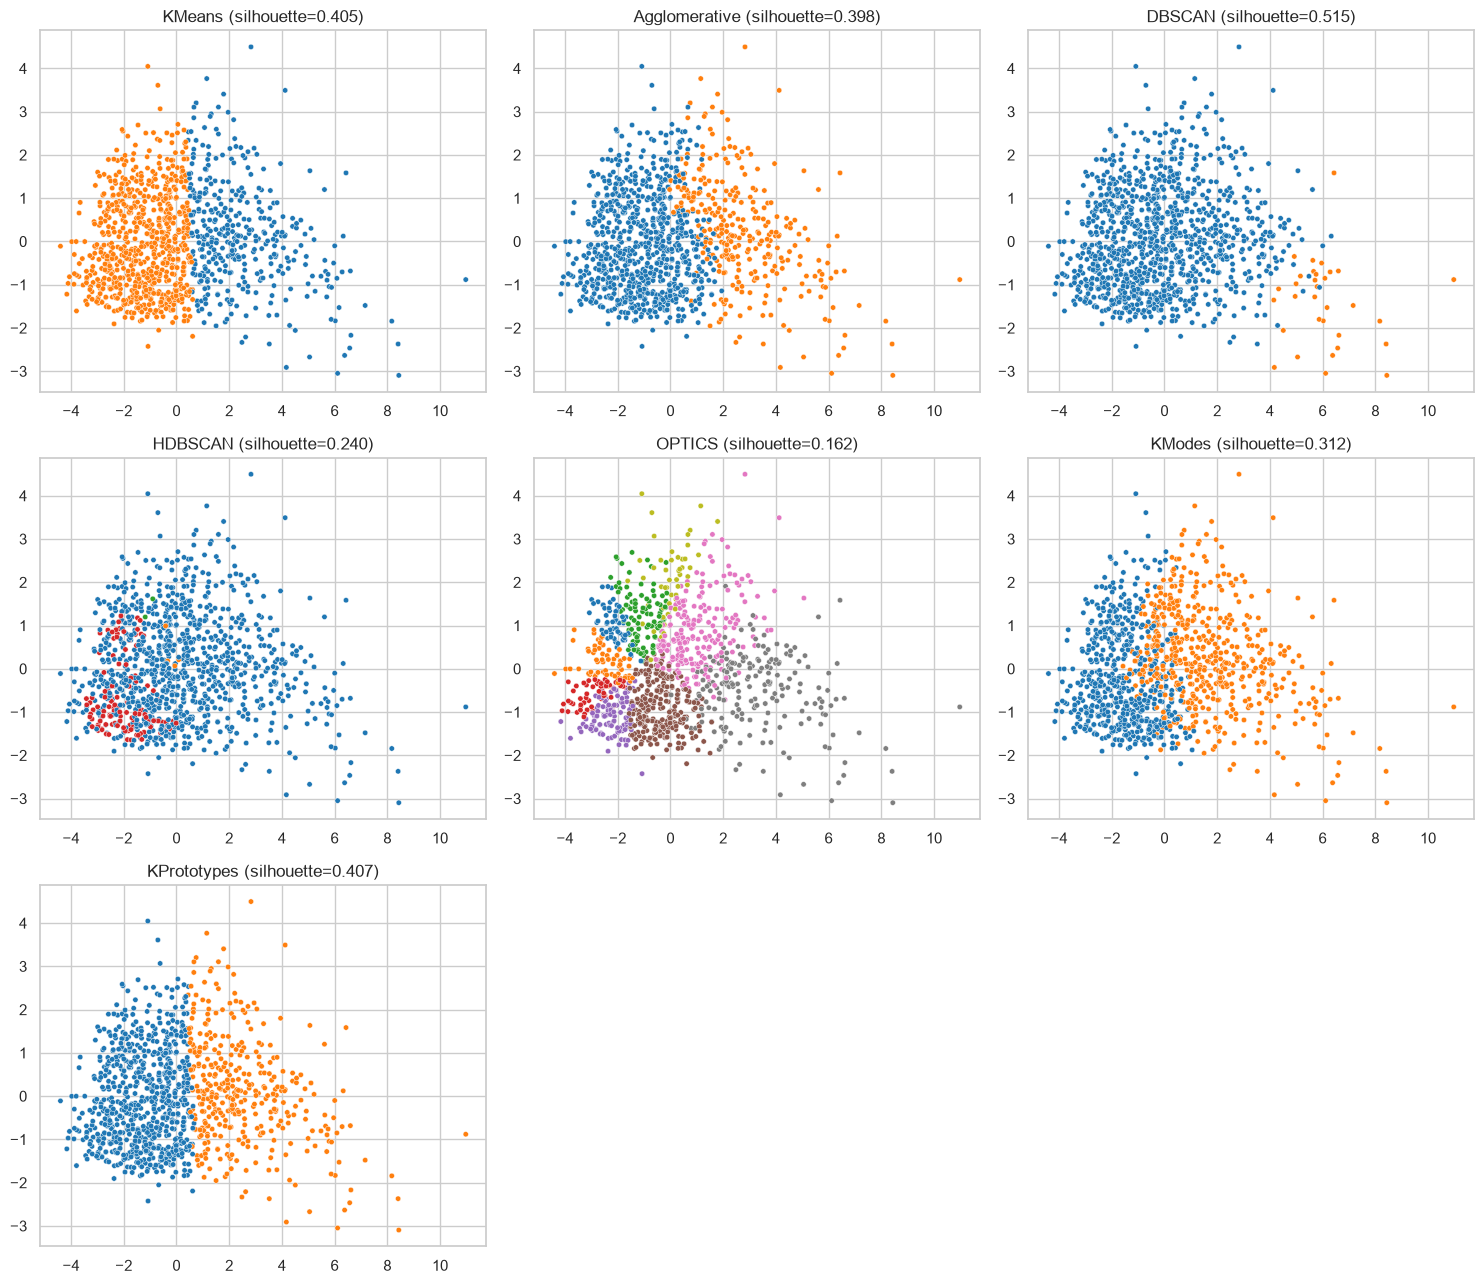

In [15]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_test_pca = pca.fit_transform(X_test_num)

modelos_labels_teste = {
    "KMeans": labels_test_kmeans,
    "Agglomerative": labels_test_agglo,
    "DBSCAN": labels_test_dbscan,
    "HDBSCAN": labels_test_hdbscan,
    "OPTICS": labels_test_optics,
    "KModes": labels_test_kmodes,
    "KPrototypes": labels_test_kproto,
}

fig, axes = plt.subplots(3, 3, figsize=(15, 13))
for ax, (nome, labels) in zip(axes.ravel(), modelos_labels_teste.items()):
    sns.scatterplot(x=X_test_pca[:, 0], y=X_test_pca[:, 1], hue=labels, palette="tab10", s=15, ax=ax, legend=False)
    sil = df_resultados.query("modelo == @nome and conjunto == 'teste'")["silhouette"].values[0]
    ax.set_title(f"{nome} (silhouette={sil:.3f})")

for ax in axes.ravel()[len(modelos_labels_teste):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(f"{PASTA_REPORTS}/comparacao_pca_todos_modelos.png", dpi=120)
plt.show()

## 13. Conclusões da comparação

**Resultados no conjunto de teste (silhouette, espaço numérico padronizado):**

| Modelo | Silhouette | Calinski-Harabasz | Davies-Bouldin | Nº clusters | Observação |
|---|---|---|---|---|---|
| DBSCAN | 0.515 | 230 | 0.61 | 2 | Maior silhouette, mas o 2º cluster é um nicho de apenas 11 municípios de porte médio; 11% do treino foi descartado como ruído |
| KPrototypes | 0.407 | 929 | 0.97 | 2 | Melhor entre os modelos "completos" (sem ruído); usa também a região |
| KMeans | 0.405 | 929 | 0.98 | 2 | Praticamente empatado com KPrototypes; simples e com `predict` nativo |
| Agglomerative | 0.398 | 826 | 0.99 | 2 | Resultado consistente com KMeans/KPrototypes |
| KModes | 0.312 | 703 | 1.13 | 2 | Usa só variáveis categóricas (quartis + região); perde informação de magnitude |
| HDBSCAN | 0.240 | 10 | 0.70 | 3 | 85-89% dos pontos viram ruído — não encontra estrutura densa ampla |
| OPTICS | 0.162 | 355 | 1.53 | 9 | 97% de ruído no treino; os "clusters" são micro-grupos de poucos pontos |

**Principais conclusões:**

1. **Todos os métodos convergem para uma separação em torno de 2 grupos**: municípios pequenos/médios (a maioria) versus municípios grandes e economicamente mais relevantes. Isso é coerente com a EDA, que já mostrava forte concentração de população e PIB em poucos municípios.
2. **KMeans, Agglomerative e KPrototypes têm desempenho muito próximo** (silhouette 0.40–0.41) e são os mais **práticos**: cobrem 100% dos municípios (sem noção de "ruído"), têm Calinski-Harabasz muito mais alto que os métodos de densidade, e são fáceis de interpretar.
3. **DBSCAN obteve o maior silhouette**, mas isso reflete principalmente sua capacidade de isolar como "ruído" os municípios mais atípicos (deixando só 2 clusters compactos, um deles com apenas 11 municípios) — é mais um detector de outliers do que uma segmentação de toda a base.
4. **HDBSCAN e OPTICS não encontraram estrutura densa ampla nos dados**: 85–97% dos municípios ficaram como ruído no treino. Isso indica que a distribuição dos municípios é mais um **gradiente contínuo** (poucos grandes, muitos pequenos) do que grupos de densidade bem definidos — cenário desfavorável para métodos baseados em densidade.
5. **KModes (somente categórico) perde desempenho** frente aos métodos numéricos, confirmando que discretizar as variáveis contínuas em quartis descarta informação relevante para a separação dos municípios.

**Modelo escolhido para o notebook final (`04_Avaliacao_Conclusao`): KPrototypes.** Ele empata tecnicamente com KMeans, mas agrega a variável `regiao` ao processo de clusterização (mais informação e melhor storytelling), evitando o comportamento de "detector de outliers" do DBSCAN e a perda de informação do KModes.